# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective

The objective of this project is to analyze the relationship between Bitcoin market sentiment and trader performance.

By combining the Bitcoin Fear & Greed Index with Hyperliquid trading activity, we aim to identify how market sentiment impacts:

1. Trading activity
2. Profitability
3. Win rates
4. Position sizing
5. Buy/Sell strategy effectiveness
6. Risk-adjusted performance

The insights can help traders and trading platforms develop more effective sentiment-aware trading strategies.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

## DataSet

The analysis uses two datasets:

1. Bitcoin Fear & Greed Index
2. Historical Hyperliquid Trading Data

The datasets are merged using trading date to associate each trade with the corresponding market sentiment.

In [30]:
fear_greed = pd.read_csv('fear_greed_index.csv')

trades = pd.read_csv(
    'historical_data.csv',
    on_bad_lines='skip',
    low_memory=False
)

print("Fear & Greed Shape:", fear_greed.shape)
print("Trades Shape:", trades.shape)

Fear & Greed Shape: (2644, 4)
Trades Shape: (211224, 16)


## Data Preparation

Key cleaning steps:

1. Converted timestamps into datetime format.
2. Corrected date parsing issues.
3. Merged sentiment labels with trade records.
4. Converted financial fields into numeric format.
5. Removed only 6 unmatched records.

In [31]:
fear_greed['date'] = pd.to_datetime(
    fear_greed['date']
)

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

trades['date'] = trades['Timestamp IST'].dt.date

fear_greed['date'] = fear_greed['date'].dt.date

print("Missing Timestamp:", trades['Timestamp IST'].isna().sum())
print("Missing Date:", trades['date'].isna().sum())

Missing Timestamp: 0
Missing Date: 0


In [32]:
df = trades.merge(
    fear_greed[['date', 'classification', 'value']],
    on='date',
    how='left'
)

print("Merged Shape:", df.shape)

print(
    "Missing Sentiment:",
    df['classification'].isna().sum()
)

Merged Shape: (211224, 19)
Missing Sentiment: 6


In [33]:
df = df.dropna(
    subset=['classification']
)

print(df.shape)

(211218, 19)


In [34]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Closed PnL',
    'Fee'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

print(df[numeric_cols].dtypes)

Execution Price    float64
Size Tokens        float64
Size USD           float64
Closed PnL         float64
Fee                float64
dtype: object


In [35]:
print(
    df[
        ['Execution Price',
         'Size Tokens',
         'Size USD',
         'Closed PnL',
         'Fee']
    ].isna().sum()
)

Execution Price    0
Size Tokens        0
Size USD           0
Closed PnL         0
Fee                0
dtype: int64


In [36]:
df['Winning Trade'] = df['Closed PnL'] > 0

print(
    df['Winning Trade']
    .value_counts()
)

Winning Trade
False    124355
True      86863
Name: count, dtype: int64


## Trading Activity Analysis

In [37]:
trade_count = (
    df['classification']
    .value_counts()
)

print(trade_count)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


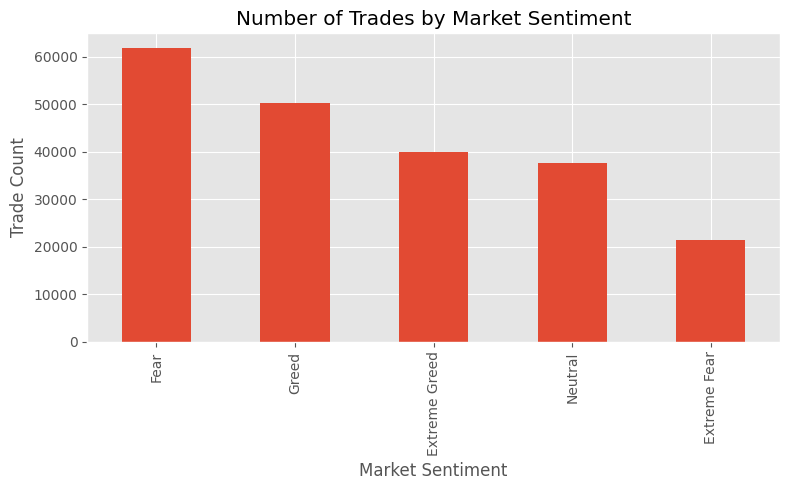

In [38]:
plt.figure(figsize=(8,5))

trade_count.plot(
    kind='bar'
)

plt.title(
    'Number of Trades by Market Sentiment'
)

plt.xlabel('Market Sentiment')
plt.ylabel('Trade Count')

plt.tight_layout()
plt.show()

## Profitability Analysis

In [39]:
sentiment_pnl = (
    df.groupby('classification')['Closed PnL']
    .agg(
        ['count', 'sum', 'mean', 'median']
    )
)

sentiment_pnl = sentiment_pnl.sort_values(
    by='mean',
    ascending=False
)

sentiment_pnl

,count,sum,mean,median
classification,,,,
Extreme Greed,39992,2.715171e+06,67.892861,0.0
Fear,61837,3.357155e+06,54.290400,0.0
Greed,50303,2.150129e+06,42.743559,0.0
Extreme Fear,21400,7.391102e+05,34.537862,0.0
Neutral,37686,1.292921e+06,34.307718,0.0


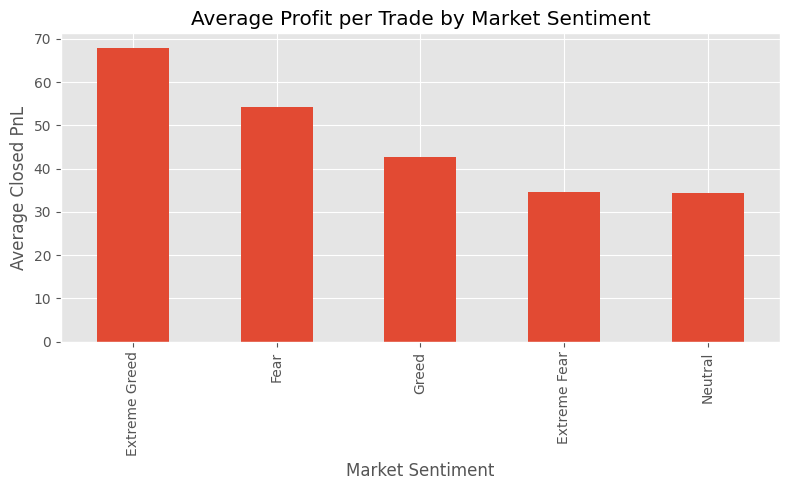

In [40]:
plt.figure(figsize=(8,5))

sentiment_pnl['mean'].plot(
    kind='bar'
)

plt.title(
    'Average Profit per Trade by Market Sentiment'
)

plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')

plt.tight_layout()
plt.show()

## Win Rate Analysis

In [41]:
win_rate = (
    df.groupby('classification')
    ['Winning Trade']
    .mean()
    * 100
)

win_rate = win_rate.sort_values(
    ascending=False
)

win_rate

,Winning Trade
classification,
Extreme Greed,46.494299
Fear,42.076750
Neutral,39.699093
Greed,38.482794
Extreme Fear,37.060748


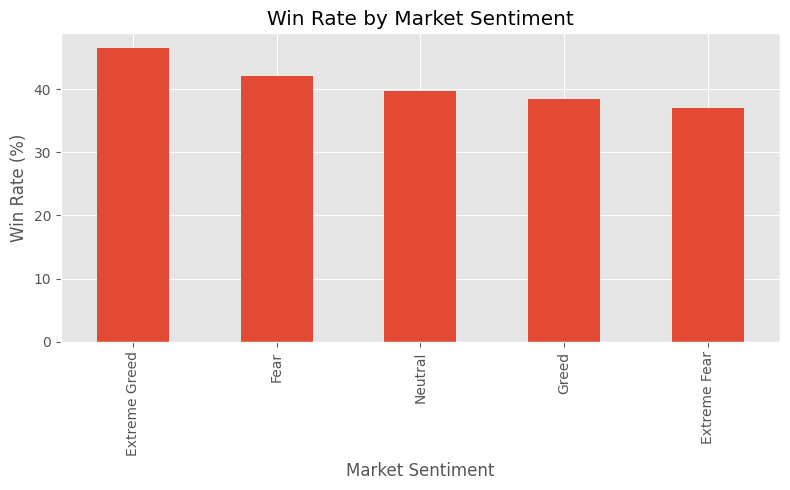

In [42]:
plt.figure(figsize=(8,5))

win_rate.plot(
    kind='bar'
)

plt.title(
    'Win Rate by Market Sentiment'
)

plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')

plt.tight_layout()
plt.show()

## Position Size Analysis

In [43]:
trade_size = (
    df.groupby('classification')
    ['Size USD']
    .agg(
        ['mean', 'median']
    )
)

trade_size = trade_size.sort_values(
    by='mean',
    ascending=False
)

trade_size

,mean,median
classification,,
Fear,7816.109931,735.960
Greed,5736.884375,555.000
Extreme Fear,5349.731843,766.150
Neutral,4782.732661,547.655
Extreme Greed,3112.251565,500.050


### Observation

Although Extreme Greed produced the highest profitability, it was associated with the smallest average trade size.

This suggests that improved trade quality rather than increased risk exposure contributed to higher returns.

## Buy vs Sell Strategy Analysis

In [44]:
buy_sell = (
    df.groupby(
        ['classification', 'Side']
    )['Closed PnL']
    .mean()
    .unstack()
)

buy_sell

Side,BUY,SELL
classification,,
Extreme Fear,34.114627,34.980106
Extreme Greed,10.498927,114.584643
Fear,63.927104,45.049641
Greed,25.002302,59.691091
Neutral,29.227429,39.456408


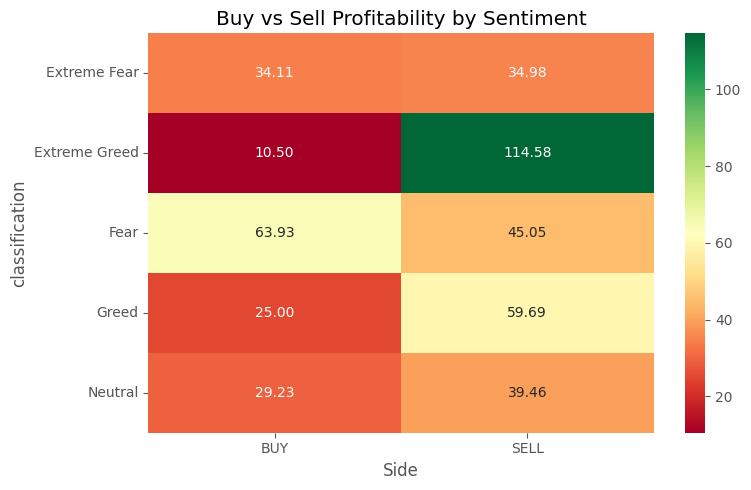

In [45]:
plt.figure(figsize=(8,5))

sns.heatmap(
    buy_sell,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn'
)

plt.title(
    'Buy vs Sell Profitability by Sentiment'
)

plt.tight_layout()
plt.show()

## Risk-Adjusted Performance Analysis

In [46]:
risk_analysis = (
    df.groupby('classification')
    ['Closed PnL']
    .agg(
        ['mean', 'std']
    )
)

risk_analysis['Risk_Adjusted_Score'] = (
    risk_analysis['mean']
    /
    risk_analysis['std']
)

risk_analysis.sort_values(
    by='Risk_Adjusted_Score',
    ascending=False
)

,mean,std,Risk_Adjusted_Score
classification,,,
Extreme Greed,67.892861,766.828294,0.088537
Neutral,34.307718,517.122220,0.066344
Fear,54.290400,935.355438,0.058043
Greed,42.743559,1116.028390,0.038300
Extreme Fear,34.537862,1136.056091,0.030402


### Observation

Extreme Greed achieved the highest risk-adjusted score, indicating that it delivered the strongest balance between profitability and volatility.

This suggests that trader performance was most efficient during highly optimistic market conditions.

## Top Trader Analysis

In [47]:
top_traders = (
    df.groupby('Account')
    .agg({
        'Closed PnL':'sum',
        'Trade ID':'count'
    })
)

top_traders.columns = [
    'Total_PnL',
    'Trade_Count'
]

top_traders['Avg_PnL_Per_Trade'] = (
    top_traders['Total_PnL']
    /
    top_traders['Trade_Count']
)

top_traders = top_traders.sort_values(
    by='Total_PnL',
    ascending=False
)

top_traders.head(10)

,Total_PnL,Trade_Count,Avg_PnL_Per_Trade
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,14733,145.481748
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,419.127768
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,21192,44.364091
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,12236,68.684419
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,40184,20.806305
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05,4356,155.589314
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05,1590,270.034947
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,1237,336.735548
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05,9893,38.319560


In [48]:
sentiment_summary = pd.concat(
    [
        sentiment_pnl['mean'],
        win_rate
    ],
    axis=1
)

sentiment_summary.columns = [
    'Average_PnL',
    'Win_Rate (%)'
]

sentiment_summary = sentiment_summary.sort_values(
    by='Average_PnL',
    ascending=False
)

sentiment_summary.round(2)

,Average_PnL,Win_Rate (%)
classification,,
Extreme Greed,67.89,46.49
Fear,54.29,42.08
Greed,42.74,38.48
Extreme Fear,34.54,37.06
Neutral,34.31,39.70


# Key Strategic Recommendations

Based on the analysis, the following strategies may improve trading performance:

1. Increase exposure to long opportunities during Fear conditions, where BUY trades showed superior profitability.

2. Consider profit-taking or short-biased strategies during Extreme Greed conditions, where SELL trades generated the highest returns.

3. Incorporate market sentiment as a feature in trading models and risk-management systems.

4. Monitor transitions from Fear to Greed, as profitability and win rates vary significantly across sentiment regimes.

5. Focus on trade quality rather than position size, as the most profitable sentiment regime (Extreme Greed) was associated with the smallest average trade sizes.

# Executive Summary

## Key Findings

1. Trading activity was highest during Fear periods.

2. Extreme Greed produced the highest average profitability per trade.

3. Extreme Greed achieved the highest win rate.

4. Traders generated the strongest risk-adjusted returns during Extreme Greed.

5. Buying during Fear and selling during Extreme Greed appeared to be the most effective sentiment-based strategy.

6. Higher profitability was achieved despite smaller average position sizes, suggesting better trade quality rather than higher risk-taking.

## Conclusion

Market sentiment has a measurable impact on trading performance.

The findings indicate that sentiment-aware trading strategies may improve both profitability and risk-adjusted returns.